# Análisis Exploratorio de Datos (EDA)
## Brazilian E-commerce Public Dataset by Olist

**Asignatura:** Diseño y Optimización de Bases de Datos  
**Programa:** Maestría en Arquitectura de Software  
**Caso de estudio:** Ecommify  

### Integrantes
- Dayan Velasquez Parrado
- Anuar Edilson Vargas Calderon

### Fecha
- 10/05/2026

---

## Propósito

El presente análisis exploratorio de datos tiene como objetivo comprender la estructura, relaciones, calidad y comportamiento general del dataset Olist, con el fin de establecer una base sólida para el diseño posterior de una arquitectura híbrida de bases de datos orientada al caso Ecommify.

## Archivos analizados

- `customers_dataset.csv`
- `orders_dataset.csv`
- `order_items_dataset.csv`
- `order_payments_dataset.csv`
- `order_reviews_dataset.csv`
- `products_dataset.csv`
- `product_category_name_translation.csv`
- `sellers_dataset.csv`
- `geolocation_dataset.csv`

## 1. Configuración del entorno y carga de datos

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from google.colab import drive

# Montar Google Drive
#drive.mount('/content/drive')

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

#base_path = "/content/drive/MyDrive/DataSets/"
base_path = "/content/sample_data/"

customers = pd.read_csv(base_path + "customers_dataset.csv")
orders = pd.read_csv(base_path + "orders_dataset.csv")
order_items = pd.read_csv(base_path + "order_items_dataset.csv")
order_payments = pd.read_csv(base_path + "order_payments_dataset.csv")
order_reviews = pd.read_csv(base_path + "order_reviews_dataset.csv")
products = pd.read_csv(base_path + "products_dataset.csv")
category_translation = pd.read_csv(base_path + "product_category_name_translation.csv")
sellers = pd.read_csv(base_path + "sellers_dataset.csv")
geolocation = pd.read_csv(base_path + "geolocation_dataset.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "category_translation": category_translation,
    "sellers": sellers,
    "geolocation": geolocation
}

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


## 2. Resumen general de los datasets

Se realiza una revisión inicial del volumen de información disponible en cada tabla para identificar el tamaño relativo de las entidades del sistema.

In [8]:
summary = pd.DataFrame([
    {
        "Dataset": name,
        "Filas": df.shape[0],
        "Columnas": df.shape[1]
    }
    for name, df in datasets.items()
]).sort_values("Filas", ascending=False).reset_index(drop=True)

display(summary)

,Dataset,Filas,Columnas
0,geolocation,1000163,5
1,order_items,112650,7
2,order_payments,103886,5
3,customers,99441,5
4,orders,99441,8
5,order_reviews,99224,7
6,products,32951,9
7,sellers,3095,4
8,category_translation,71,2


### Hallazgo

Las tablas con mayor volumen son `geolocation`, `order_items`, `order_payments`, `order_reviews`, `orders` y `customers`, lo que evidencia que el dataset está centrado en el flujo transaccional de compra y en la cobertura geográfica del territorio.

## 3. Estructura de la información

A continuación se revisan las columnas, tipos de datos y primeras filas de las tablas principales.

In [9]:
for name, df in datasets.items():
    print(f"\n{'='*80}")
    print(f"  {name.upper()}")
    print(f"{'='*80}")
    display(df.head(3))
    display(df.dtypes.to_frame("Tipo de dato"))


  CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


,Tipo de dato
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object



  ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


,Tipo de dato
seller_id,object
seller_zip_code_prefix,int64
seller_city,object
seller_state,object



  GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


,Tipo de dato
geolocation_zip_code_prefix,int64
geolocation_lat,float64
geolocation_lng,float64
geolocation_city,object
geolocation_state,object


## 4. Calidad de datos

### 4.1 Valores nulos

Se analizan los valores faltantes para identificar posibles limitaciones del dataset y su impacto sobre consultas, integridad y decisiones de diseño.

In [10]:
nulls = pd.DataFrame([
    {
        "Dataset": name,
        "Columna": col,
        "Nulos": int(count),
        "Porcentaje (%)": round(count / len(df) * 100, 2)
    }
    for name, df in datasets.items()
    for col, count in df.isnull().sum().items()
    if count > 0
]).sort_values(["Dataset", "Nulos"], ascending=[True, False]).reset_index(drop=True)

display(nulls)

,Dataset,Columna,Nulos,Porcentaje (%)
0,order_reviews,review_comment_title,87656,88.34
1,order_reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
3,orders,order_delivered_carrier_date,1783,1.79
4,orders,order_approved_at,160,0.16
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
9,products,product_weight_g,2,0.01


### Hallazgos

Se identifican valores nulos relevantes en:
- **`orders`**: fechas de aprobación y entrega (órdenes canceladas o en proceso).
- **`order_reviews`**: títulos y mensajes de comentarios (reseñas solo con calificación numérica).
- **`products`**: atributos descriptivos como categoría, nombre y dimensiones en casos puntuales.

**4.1.1. valores atipicos en los conjuntos de datos**



In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

all_outliers = []

for df_name, df in datasets.items():
    print(f"\n--- Analizando outliers en {df_name} ---")
    numerical_cols = df.select_dtypes(include=np.number).columns

    if numerical_cols.empty:
        print(f"No hay columnas numéricas en {df_name}.")
        continue

    for col in numerical_cols:
        # Excluir columnas con muchos valores únicos que podrían ser IDs, a menos que el usuario especifique lo contrario
        # O si son columnas que no suelen tener outliers (ej: scores discretos como review_score)
        if df_name == 'order_reviews' and col == 'review_score':
            continue # review_score es un valor discreto de 1 a 5, los outliers no son relevantes aquí.

        outliers_df = detect_outliers_iqr(df, col)

        if not outliers_df.empty:
            num_outliers = len(outliers_df)
            pct_outliers = (num_outliers / len(df)) * 100
            print(f"  Columna '{col}': {num_outliers} outliers detectados ({pct_outliers:.2f}% de las filas).")
            all_outliers.append({
                'Dataset': df_name,
                'Columna': col,
                'Num_Outliers': num_outliers,
                'Porcentaje_Outliers': round(pct_outliers, 2),
                'Ejemplo_Outliers': outliers_df[col].head(3).tolist() # Mostrar algunos ejemplos
            })
        else:
            print(f"  Columna '{col}': No se detectaron outliers.")

if all_outliers:
    outliers_summary_df = pd.DataFrame(all_outliers)
    print("\n--- Resumen de Outliers Detectados ---")
    display(outliers_summary_df)
else:
    print("No se detectaron outliers en ninguna columna numérica de los datasets.")


--- Analizando outliers en customers ---
  Columna 'customer_zip_code_prefix': No se detectaron outliers.

--- Analizando outliers en orders ---
  Columna 'delivery_delay_days': 4301 outliers detectados (4.33% de las filas).

--- Analizando outliers en order_items ---
  Columna 'order_item_id': 13984 outliers detectados (12.41% de las filas).
  Columna 'price': 8427 outliers detectados (7.48% de las filas).
  Columna 'freight_value': 12134 outliers detectados (10.77% de las filas).

--- Analizando outliers en order_payments ---
  Columna 'payment_sequential': 4526 outliers detectados (4.36% de las filas).
  Columna 'payment_installments': 6313 outliers detectados (6.08% de las filas).
  Columna 'payment_value': 7981 outliers detectados (7.68% de las filas).

--- Analizando outliers en order_reviews ---

--- Analizando outliers en products ---
  Columna 'product_name_lenght': 290 outliers detectados (0.88% de las filas).
  Columna 'product_description_lenght': 2078 outliers detectados 

,Dataset,Columna,Num_Outliers,Porcentaje_Outliers,Ejemplo_Outliers
0,orders,delivery_delay_days,4301,4.33,"[11.0, 9.0, 17.0]"
1,order_items,order_item_id,13984,12.41,"[2, 2, 3]"
2,order_items,price,8427,7.48,"[810.0, 639.0, 289.0]"
3,order_items,freight_value,12134,10.77,"[70.75, 44.4, 44.29]"
4,order_payments,payment_sequential,4526,4.36,"[2, 2, 2]"
5,order_payments,payment_installments,6313,6.08,"[10, 10, 10]"
6,order_payments,payment_value,7981,7.68,"[353.09, 541.0, 542.66]"
7,products,product_name_lenght,290,0.88,"[19.0, 18.0, 17.0]"
8,products,product_description_lenght,2078,6.31,"[2083.0, 3021.0, 1987.0]"
9,products,product_photos_qty,849,2.58,"[9.0, 9.0, 9.0]"


###Hallazgos

Se identifican valores atípicos en varios conjuntos de datos, los cuales se se desvían notablemente de la tendencia general dentro de un conjunto de datos. Reconocer la presencia de valores atípicos es crucial para mantener la integridad de los análisis de datos y garantizar la precisión en las interpretaciones

### 4.2 Unicidad de claves

*   Se identifican los campos simple y compuestos unicos que seran las llaves pontenciales



In [25]:
uniqueness = pd.DataFrame({
    "Campo": [
        "customers.customer_id",
        "customers.customer_unique_id",
        "orders.order_id",
        "order_items.order_id",
         "products.product_id",
        "sellers.seller_id",
        "order_reviews.review_id", # Clave lógica, con duplicados
        "order_payments.order_id", # Unicidad del order_id individual en pagos
        "category_translation.product_category_name",
        "geolocation.geolocation_zip_code_prefix", # Unicidad del prefijo postal
        "geolocation.geolocation_lat_lng", # Unicidad de lat/lng
        "(order_items.order_id, order_items.order_item_id)",  # Clave compuesta
        "(order_payments.order_id, order_payments.payment_sequential)",  # Clave compuesta
        "(order_reviews.order_id, order_reviews.review_id)",  # Clave compuesta
        "(geolocation.geolocation_zip_code_prefix, geolocation.geolocation_lat, geolocation.geolocation_lng)" # Clave compuesta
    ],
    "Es único": [
        customers["customer_id"].is_unique,
        customers["customer_unique_id"].is_unique,
        orders["order_id"].is_unique,
        order_items["order_id"].is_unique,
        products["product_id"].is_unique,
        sellers["seller_id"].is_unique,
        order_reviews["review_id"].is_unique,
        order_payments["order_id"].is_unique,
        category_translation["product_category_name"].is_unique,
        geolocation["geolocation_zip_code_prefix"].is_unique,
        ~geolocation.duplicated(subset=["geolocation_lat", "geolocation_lng"]).any(),
        ~order_items.duplicated(subset=["order_id", "order_item_id"]).any(),  # Clave compuesta
        ~order_payments.duplicated(subset=["order_id", "payment_sequential"]).any(),  # Clave compuesta
        ~order_reviews.duplicated(subset=["order_id", "review_id"]).any(),  # Clave compuesta
        ~geolocation.duplicated(subset=["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]).any() # Clave compuesta
    ]
})

display(uniqueness)

,Campo,Es único
0,customers.customer_id,True
1,customers.customer_unique_id,False
2,orders.order_id,True
3,order_items.order_id,False
4,products.product_id,True
5,sellers.seller_id,True
6,order_reviews.review_id,False
7,order_payments.order_id,False
8,category_translation.product_category_name,True
9,geolocation.geolocation_zip_code_prefix,False


### Hallazgos

- `order_payments.order_id` no es único: una orden puede pagarse en múltiples partes.
- `customers.customer_unique_id` puede repetirse: un mismo cliente lógico puede tener múltiples órdenes.
- `order_reviews.review_id` presenta duplicados y debe revisarse antes de adoptarlo como clave primaria.
- `order_items` presenta una llave compuesta y se verifica que la combinacción es unica.
- `order_payments` presenta una llave compuesta y se verifica que la combinacción es unica.
- `order_review_order` presenta una llave compuesta y se verifica que la combinacción es unica.
- `geolocation` no presenta una llave unica.

```
# Esto tiene formato de código
```



###4.2.1.Verificación de Unicidad en `order_reviews`

Vamos a comprobar explícitamente la unicidad de las columnas clave en el DataFrame `order_reviews`.

In [19]:
# Verificar la unicidad de 'review_id'
is_review_id_unique = order_reviews["review_id"].is_unique
print(f"¿'review_id' es único en order_reviews? {is_review_id_unique}")

# Verificar la unicidad de 'order_id'
is_order_id_unique = order_reviews["order_id"].is_unique
print(f"¿'order_id' es único en order_reviews? {is_order_id_unique}")

# Si 'review_id' no es único, mostramos los duplicados
if not is_review_id_unique:
    print("\nMostrando los 'review_id' duplicados en order_reviews:")
    duplicated_review_ids = order_reviews[order_reviews["review_id"].duplicated(keep=False)].sort_values(by="review_id")
    display(duplicated_review_ids.head())
else:
    print("\n'review_id' es completamente único, no hay duplicados.")

¿'review_id' es único en order_reviews? False
¿'order_id' es único en order_reviews? False

Mostrando los 'review_id' duplicados en order_reviews:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53


**Hallazgos**

No hay unicidad de las columnas de order_reviews. se presenta datos duplicados en la combinacion order_id y *review_id*

## 5. Relaciones entre entidades

Se valida la correspondencia entre claves foráneas y entidades principales para verificar consistencia referencial.

In [26]:
relationships = pd.DataFrame({
    "Relación": [
        "orders → customers",
        "order_items → orders",
        "order_items → products",
        "order_items → sellers",
        "order_payments → orders",
        "order_reviews → orders"
    ],
    "Coincidencia (%)": [
        round(orders["customer_id"].isin(customers["customer_id"]).mean() * 100, 2),
        round(order_items["order_id"].isin(orders["order_id"]).mean() * 100, 2),
        round(order_items["product_id"].isin(products["product_id"]).mean() * 100, 2),
        round(order_items["seller_id"].isin(sellers["seller_id"]).mean() * 100, 2),
        round(order_payments["order_id"].isin(orders["order_id"]).mean() * 100, 2),
        round(order_reviews["order_id"].isin(orders["order_id"]).mean() * 100, 2),
    ]
})

display(relationships)

,Relación,Coincidencia (%)
0,orders → customers,100.0
1,order_items → orders,100.0
2,order_items → products,100.0
3,order_items → sellers,100.0
4,order_payments → orders,100.0
5,order_reviews → orders,100.0


In [27]:
items_per_order    = order_items.groupby("order_id").size()
payments_per_order = order_payments.groupby("order_id").size()
reviews_per_order  = order_reviews.groupby("order_id").size()

cardinality = pd.DataFrame({
    "Métrica": [
        "Promedio de ítems por orden",    "Máximo de ítems por orden",
        "Promedio de pagos por orden",    "Máximo de pagos por orden",
        "Promedio de reseñas por orden",  "Máximo de reseñas por orden"
    ],
    "Valor": [
        round(items_per_order.mean(), 2),    items_per_order.max(),
        round(payments_per_order.mean(), 2), payments_per_order.max(),
        round(reviews_per_order.mean(), 2),  reviews_per_order.max()
    ]
})

display(cardinality)

,Métrica,Valor
0,Promedio de ítems por orden,1.14
1,Máximo de ítems por orden,21.00
2,Promedio de pagos por orden,1.04
3,Máximo de pagos por orden,29.00
4,Promedio de reseñas por orden,1.01
5,Máximo de reseñas por orden,3.00


### Hallazgo

Las relaciones presentan consistencia general. Se confirma una relación **1:N** entre órdenes e ítems, así como multiplicidad en pagos y reseñas, lo que respalda un diseño normalizado para la capa transaccional.

## 6. Consistencia semántica de categorías

Se valida si todas las categorías de producto poseen traducción en la tabla correspondiente.

In [28]:
unmatched = sorted(
    set(products["product_category_name"].dropna()) -
    set(category_translation["product_category_name"])
)

print(f"Categorías sin traducción: {len(unmatched)}")
print(unmatched)

Categorías sin traducción: 2
['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']


### Hallazgo

Se identifican categorías sin traducción en la tabla de equivalencias, lo cual representa una inconsistencia semántica a considerar en fases posteriores de integración y análisis.

## 7. Análisis temporal

Se estudia el comportamiento de las órdenes a lo largo del tiempo y el desempeño general de las entregas.

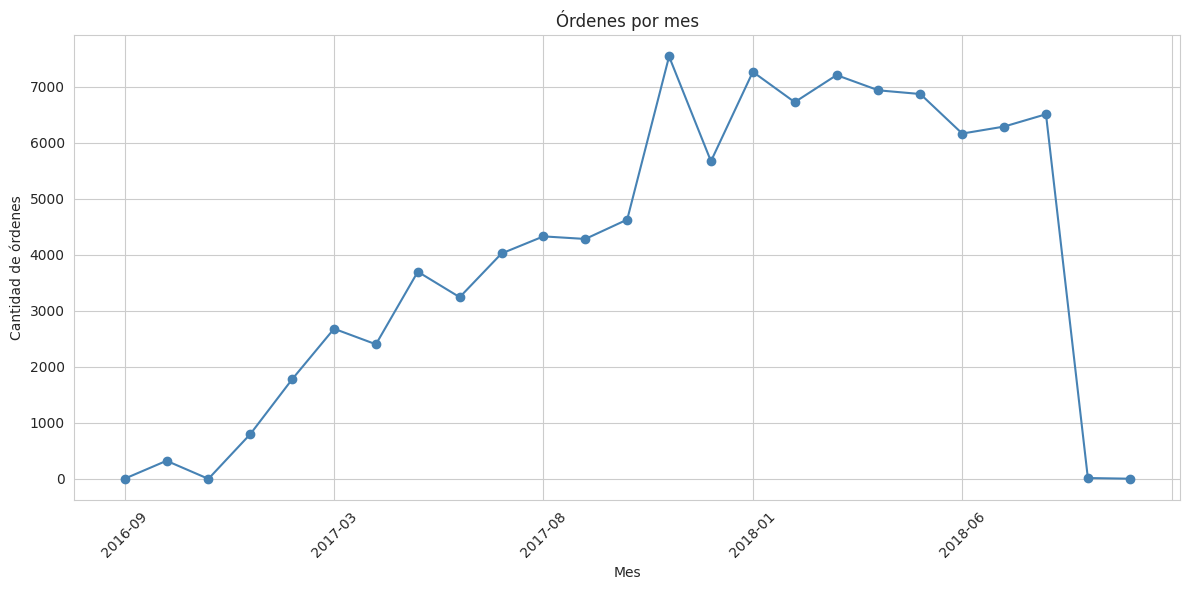

In [29]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
monthly_orders = orders.groupby("purchase_month").size()

monthly_orders.plot(marker="o", color="steelblue")
plt.title("Órdenes por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de órdenes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4149/828090005.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


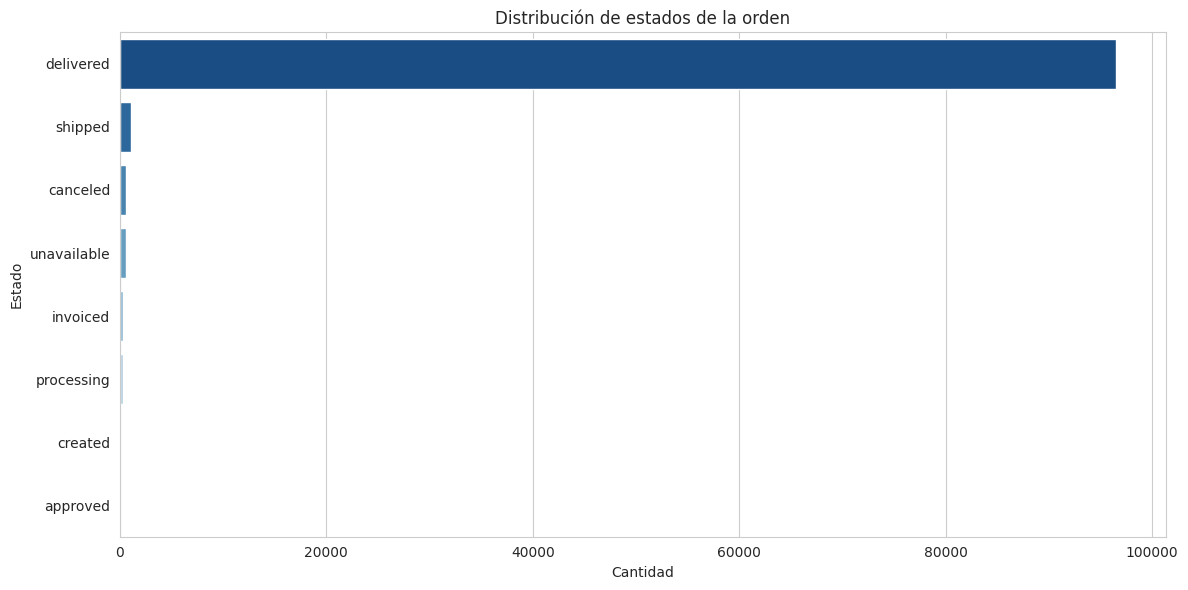

In [30]:
sns.countplot(
    data=orders,
    y="order_status",
    order=orders["order_status"].value_counts().index,
    palette="Blues_r"
)
plt.title("Distribución de estados de la orden")
plt.xlabel("Cantidad")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

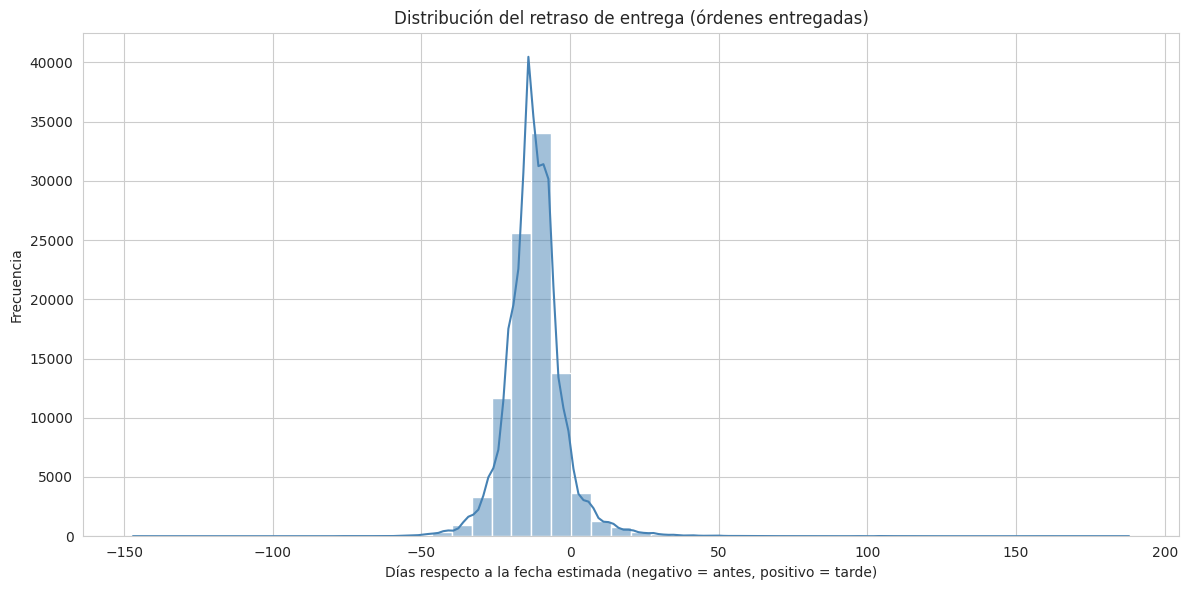

,Métrica,Valor
0,Entregas tardías (%),6.77
1,Entregas anticipadas (%),91.88
2,Entregas exactas (%),1.34


In [31]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

delivered = orders[orders["order_status"] == "delivered"].copy()

sns.histplot(delivered["delivery_delay_days"].dropna(), bins=50, kde=True, color="steelblue")
plt.title("Distribución del retraso de entrega (órdenes entregadas)")
plt.xlabel("Días respecto a la fecha estimada (negativo = antes, positivo = tarde)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

late_pct    = round((delivered["delivery_delay_days"] > 0).mean() * 100, 2)
early_pct   = round((delivered["delivery_delay_days"] < 0).mean() * 100, 2)
on_time_pct = round((delivered["delivery_delay_days"] == 0).mean() * 100, 2)

display(pd.DataFrame({
    "Métrica": ["Entregas tardías (%)", "Entregas anticipadas (%)", "Entregas exactas (%)"],
    "Valor":   [late_pct, early_pct, on_time_pct]
}))

### Hallazgos

El dataset cubre transacciones entre 2016 y 2018, con un pico de actividad hacia finales de 2017. La mayoría de las órdenes corresponden al estado `delivered`, y el comportamiento logístico muestra que gran parte de las entregas se realizaron antes de la fecha estimada.

## 8. Análisis geográfico básico

Se explora la distribución territorial de clientes y vendedores a nivel de estado y ciudad.

/tmp/ipykernel_4149/2751672558.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customer_states.values, y=top_customer_states.index, ax=axes[0], palette="Blues_r")
/tmp/ipykernel_4149/2751672558.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_seller_states.values, y=top_seller_states.index, ax=axes[1], palette="Greens_r")


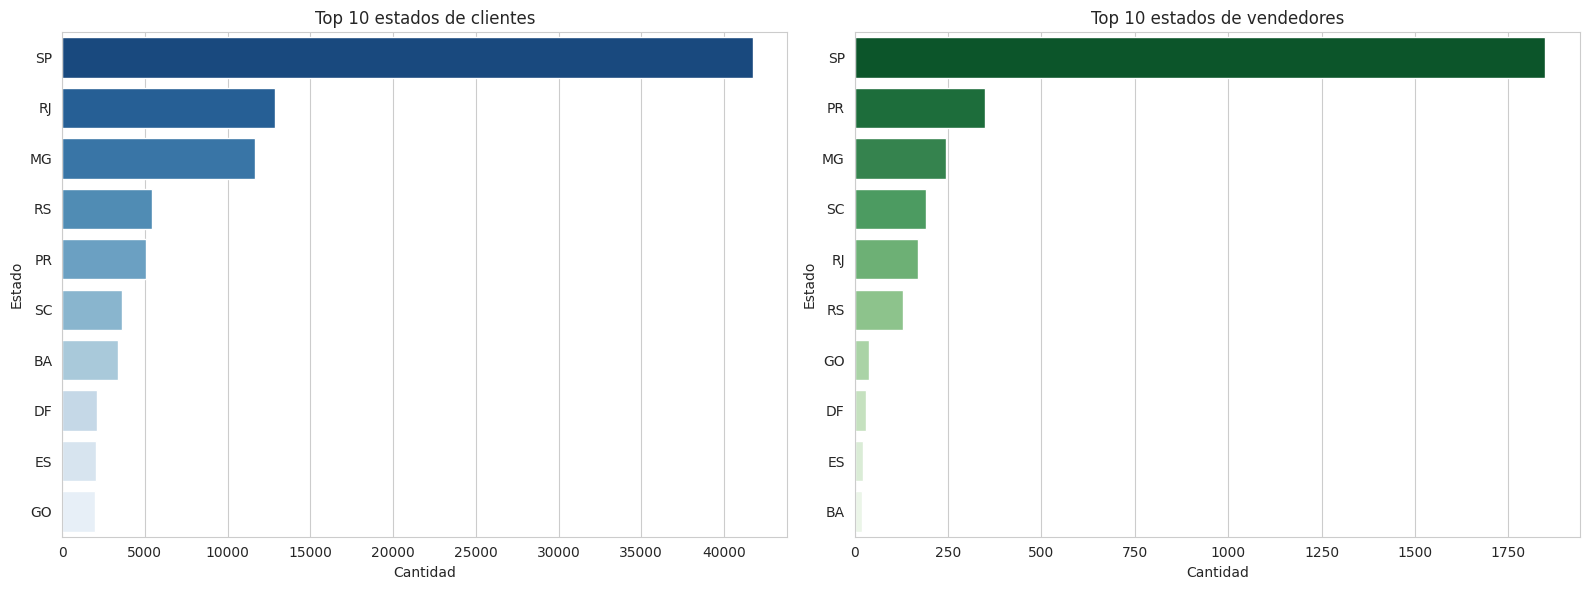

In [32]:
top_customer_states = customers["customer_state"].value_counts().head(10)
top_seller_states   = sellers["seller_state"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_customer_states.values, y=top_customer_states.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 estados de clientes")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("Estado")

sns.barplot(x=top_seller_states.values, y=top_seller_states.index, ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 10 estados de vendedores")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("Estado")

plt.tight_layout()
plt.show()

### Hallazgo

Se observa una alta concentración tanto de clientes como de vendedores en el estado de **São Paulo**, lo que sugiere centralización geográfica del mercado y posibles implicaciones logísticas.

## 9. Enriquecimiento geográfico con Geolocation

Se incorpora la tabla de geolocalización para profundizar en el análisis espacial. Dado que un mismo código postal puede tener múltiples registros de coordenadas, se genera una versión resumida calculando el promedio de latitud y longitud por prefijo único.

Este procedimiento permite enriquecer las entidades de Clientes y Vendedores sin comprometer el rendimiento del análisis.

In [33]:
# Resumen por prefijo de código postal
geo_summary = geolocation.groupby("geolocation_zip_code_prefix").agg(
    geolocation_lat   = ("geolocation_lat", "mean"),
    geolocation_lng   = ("geolocation_lng", "mean"),
    geolocation_city  = ("geolocation_city",  lambda x: x.mode().iloc[0]),
    geolocation_state = ("geolocation_state", lambda x: x.mode().iloc[0])
).reset_index()

print(f"Registros originales en geolocation : {len(geolocation):,}")
print(f"Prefijos geográficos únicos          : {len(geo_summary):,}")
display(geo_summary.head())

Registros originales en geolocation : 1,000,163
Prefijos geográficos únicos          : 19,015


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550190,-46.634024,sao paulo,SP
1,1002,-23.548146,-46.634979,sao paulo,SP
2,1003,-23.548994,-46.635731,sao paulo,SP
3,1004,-23.549799,-46.634757,sao paulo,SP
4,1005,-23.549456,-46.636733,sao paulo,SP


In [34]:
# Enriquecimiento de Clientes y Vendedores
customers_geo = customers.merge(
    geo_summary,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

sellers_geo = sellers.merge(
    geo_summary,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

print(f"Clientes con coordenadas  : {customers_geo['geolocation_lat'].notna().sum():,}")
print(f"Vendedores con coordenadas: {sellers_geo['geolocation_lat'].notna().sum():,}")

Clientes con coordenadas  : 99,163
Vendedores con coordenadas: 3,088


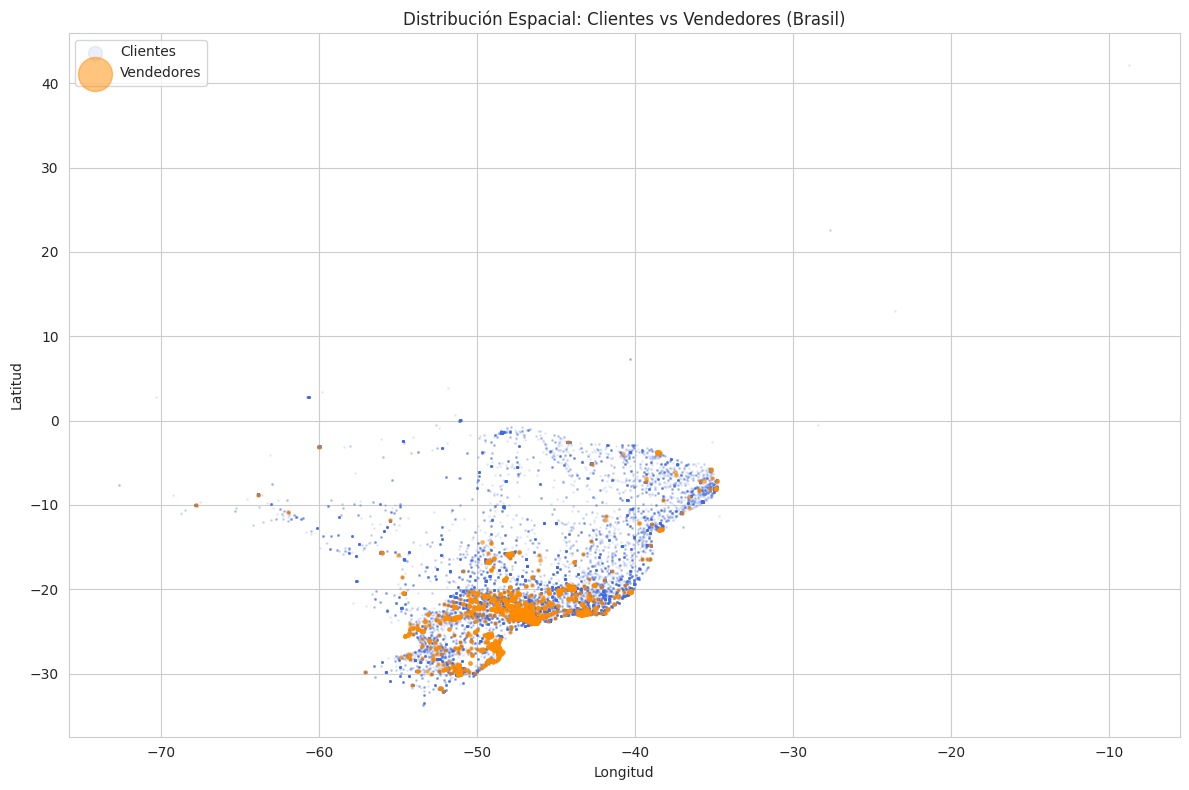

In [35]:
# Distribución espacial: Clientes vs Vendedores
plt.figure(figsize=(12, 8))

plt.scatter(
    customers_geo["geolocation_lng"],
    customers_geo["geolocation_lat"],
    s=1, alpha=0.1, color="royalblue", label="Clientes"
)

plt.scatter(
    sellers_geo["geolocation_lng"],
    sellers_geo["geolocation_lat"],
    s=6, alpha=0.5, color="darkorange", label="Vendedores"
)

plt.title("Distribución Espacial: Clientes vs Vendedores (Brasil)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(markerscale=10)
plt.tight_layout()
plt.show()

### Hallazgos

1. **Cobertura:** Se identificaron más de 19,000 prefijos postales únicos, lo que garantiza una cobertura capilar del territorio nacional.
2. **Distribución espacial:** El mapa de dispersión revela que la presencia de clientes cubre gran parte del litoral y el interior poblado, mientras que los vendedores muestran una concentración más densa en los nodos comerciales del sureste.
3. **Consistencia:** El proceso de limpieza por moda para ciudades mitiga inconsistencias de escritura detectadas en la fuente original (ej. `"sao paulo"` vs `"são paulo"`).

# 9.1 Productos más vendidos por año



In [49]:
# Extraer el año de la fecha de compra
products_sales_geo['purchase_year'] = products_sales_geo['order_purchase_timestamp'].dt.year

# Agrupar por año y categoría de producto para contar las ventas
yearly_product_sales = products_sales_geo.groupby([
    'purchase_year',
    'product_category_name'
]).size().reset_index(name='sales_count')

# Encontrar las top 5 categorías por año
def get_top_categories_yearly(df_group):
    return df_group.nlargest(5, 'sales_count')

top_yearly_product_sales = yearly_product_sales.groupby('purchase_year').apply(get_top_categories_yearly).reset_index(drop=True)

print("Datos agregados y top categorías por año calculadas.")
display(top_yearly_product_sales.head())

Datos agregados y top categorías por año calculadas.


/tmp/ipykernel_4149/153158936.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_yearly_product_sales = yearly_product_sales.groupby('purchase_year').apply(get_top_categories_yearly).reset_index(drop=True)


,purchase_year,product_category_name,sales_count
0,2016,moveis_decoracao,65
1,2016,beleza_saude,43
2,2016,perfumaria,29
3,2016,brinquedos,24
4,2016,esporte_lazer,17


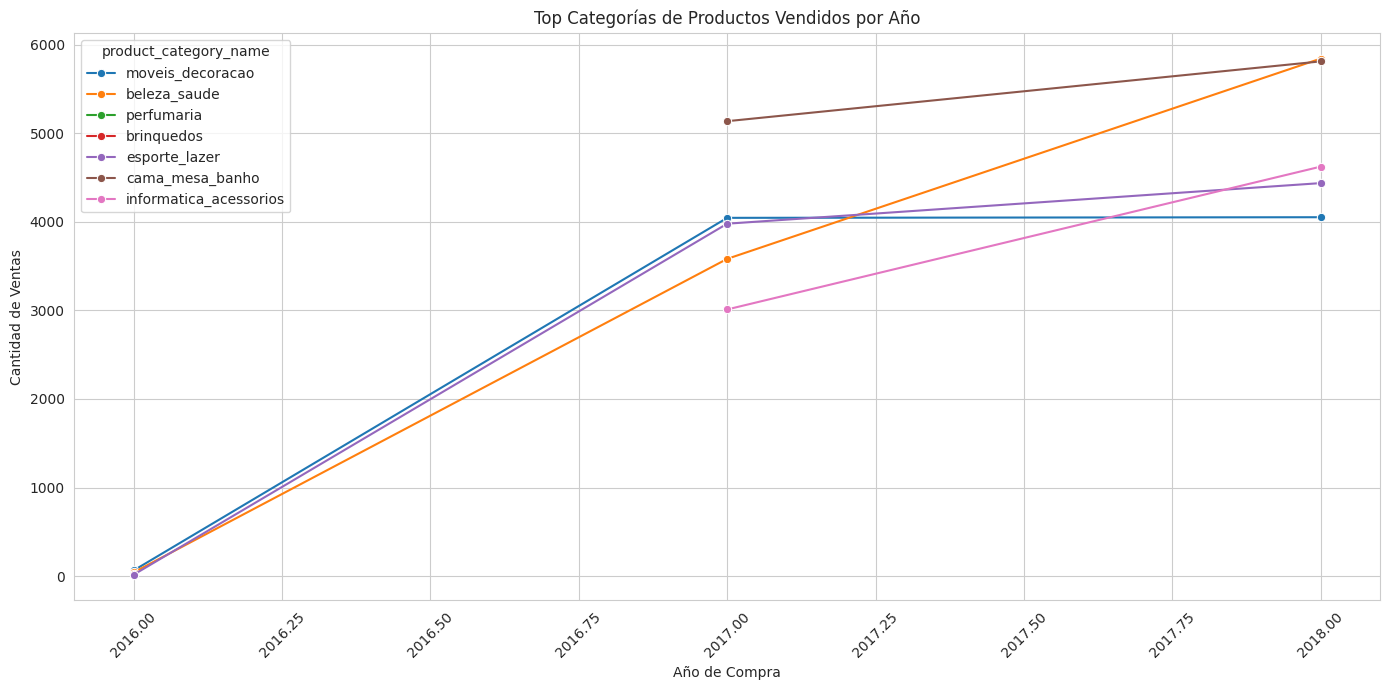

In [50]:
# Visualizar la serie temporal de productos más vendidos por año

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=top_yearly_product_sales,
    x='purchase_year',
    y='sales_count',
    hue='product_category_name',
    palette='tab10',
    marker='o'
)
plt.title('Top Categorías de Productos Vendidos por Año')
plt.xlabel('Año de Compra')
plt.ylabel('Cantidad de Ventas')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Variables de negocio complementarias

Se analizan distribuciones relacionadas con pagos y reseñas, componentes relevantes tanto en el módulo transaccional como en el analítico.

/tmp/ipykernel_4149/1144726949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_4149/1144726949.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


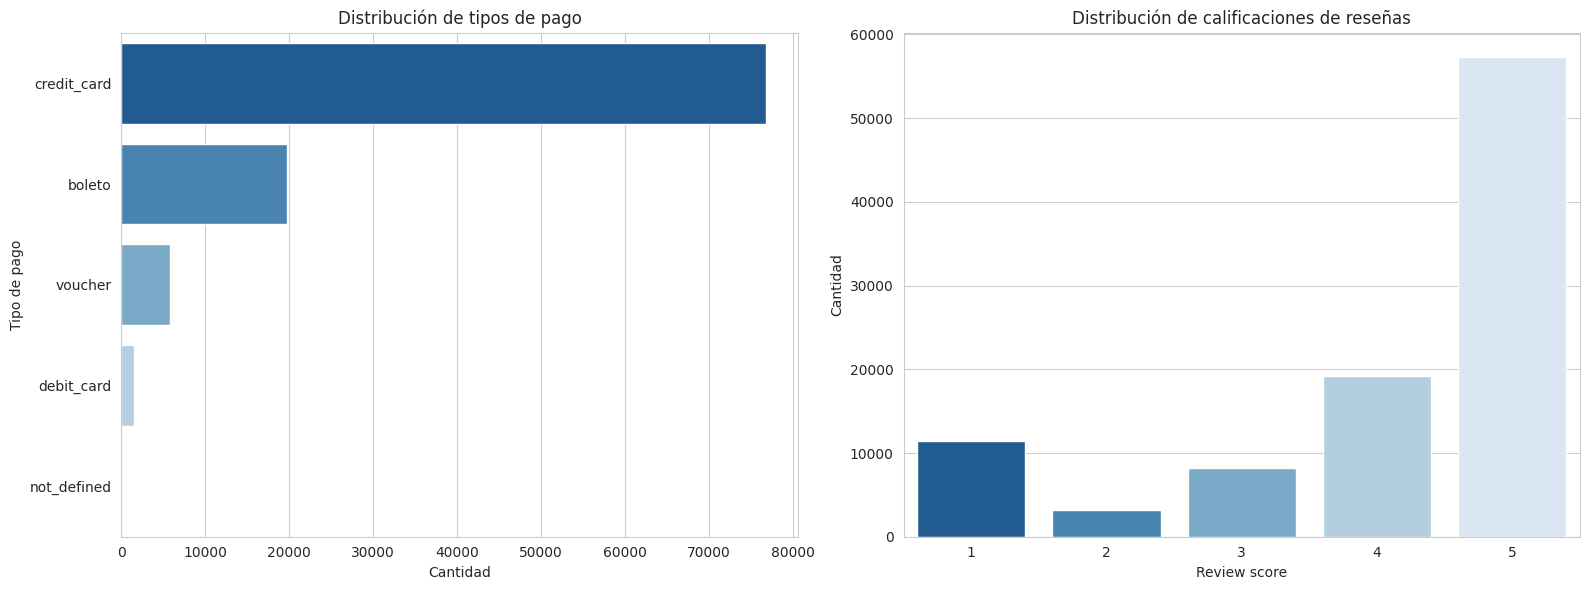

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tipos de pago
sns.countplot(
    data=order_payments,
    y="payment_type",
    order=order_payments["payment_type"].value_counts().index,
    palette="Blues_r",
    ax=axes[0]
)
axes[0].set_title("Distribución de tipos de pago")
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("Tipo de pago")

# Calificaciones de reseñas
sns.countplot(
    data=order_reviews,
    x="review_score",
    order=sorted(order_reviews["review_score"].dropna().unique()),
    palette="Blues_r",
    ax=axes[1]
)
axes[1].set_title("Distribución de calificaciones de reseñas")
axes[1].set_xlabel("Review score")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

### Interpretación

El método de pago predominante es la **tarjeta de crédito**, seguido por **boleto**. En cuanto a reseñas, la distribución de `review_score` muestra una tendencia positiva, con la mayoría de calificaciones en 5 estrellas, lo que puede ser relevante para análisis de satisfacción del cliente en fases posteriores.

## 11. Métricas clave del dataset

In [37]:
final_metrics = pd.DataFrame({
    "Indicador": [
        "Total de clientes",
        "Total de órdenes",
        "Total de ítems de orden",
        "Total de pagos",
        "Total de reseñas",
        "Total de productos",
        "Total de vendedores",
        "Prefijos geográficos únicos",
        "Promedio de ítems por orden",
        "Promedio de pagos por orden",
        "Promedio de reseñas por orden",
        "Mes con mayor número de órdenes",
        "Porcentaje de entregas tardías (%)"
    ],
    "Valor": [
        customers.shape[0],
        orders.shape[0],
        order_items.shape[0],
        order_payments.shape[0],
        order_reviews.shape[0],
        products.shape[0],
        sellers.shape[0],
        len(geo_summary),
        round(items_per_order.mean(), 2),
        round(payments_per_order.mean(), 2),
        round(reviews_per_order.mean(), 2),
        monthly_orders.idxmax(),
        late_pct
    ]
})

display(final_metrics)

,Indicador,Valor
0,Total de clientes,99441
1,Total de órdenes,99441
2,Total de ítems de orden,112650
3,Total de pagos,103886
4,Total de reseñas,99224
5,Total de productos,32951
6,Total de vendedores,3095
7,Prefijos geográficos únicos,19015
8,Promedio de ítems por orden,1.14
9,Promedio de pagos por orden,1.04


## 12. Conclusiones

El análisis exploratorio permitió comprender la estructura y características del dataset Olist, validando su utilidad para el diseño de una solución de datos para Ecommify.

Se identificó un núcleo fuertemente **transaccional** compuesto por órdenes, pagos e ítems, junto con componentes **descriptivos y analíticos** como productos, categorías y reseñas. La incorporación de la tabla de geolocalización enriqueció el análisis territorial, confirmando la concentración de actividad en el sureste del país.

Los hallazgos más relevantes son:

1. El dataset presenta una estructura relacional clara, centrada en `orders` como entidad núcleo.
2. Las relaciones entre tablas son consistentes y presentan alta integridad referencial.
3. La multiplicidad en `order_items` y `order_payments` confirma la necesidad de un modelo normalizado para la capa transaccional.
4. Se identificaron valores nulos en fechas logísticas, comentarios de reseñas y atributos descriptivos de productos.
5. Existen inconsistencias semánticas en la traducción de categorías y en la escritura de nombres de ciudades.
6. El dataset cubre el periodo 2016–2018, con un pico de actividad en noviembre de 2017.
7. Tanto clientes como vendedores se concentran principalmente en **São Paulo**.

Estos hallazgos constituyen la base para avanzar hacia el **modelado conceptual, lógico y físico** de la solución propuesta, así como para la toma de decisiones arquitectónicas en la implementación híbrida **PostgreSQL–MongoDB** de Ecommify.